### Name: Jivan Sawant
### Roll No : TEBD23277
### Practical no : 4

Create a Linear Regression Model using Python/R to predict home prices using Boston Housing Dataset
(https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains information about various
houses in Boston through different parameters. There are 506 samples and 14 feature variables in this dataset.

Linear Regression is used to predict continuous values (numbers).
RMSE (Root Mean Square Error) → error in prediction
R² Score → how well model fits
Low RMSE = good
R² close to 1 = good

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
housing_df = pd.read_csv("4simple_housing_large.csv")
housing_df.head()

,Size_sqft,Bedrooms,Bathrooms,Floors,Age,Distance_to_City,Parking,Garden,Price
0,4771.0,5.0,3.0,1,9,15,2,1,319092.591031
1,1720.0,1.0,2.0,2,2,9,2,1,108944.720469
2,1037.0,3.0,2.0,1,28,10,1,0,12462.981674
3,3050.0,4.0,NaN,3,6,20,2,0,209001.387715
4,4807.0,1.0,4.0,2,34,1,0,1,224712.645348


In [11]:
# Data Exploration and Understanding
print("Shape and Size: ", housing_df.shape, housing_df.size)
print("Shape:", housing_df.shape)
print("\nColumns:\n", housing_df.columns)
print("\nSummary:\n", housing_df.describe())

Shape and Size:  (500, 9) 4500
Shape: (500, 9)

Columns:
 Index(['Size_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Age',
       'Distance_to_City', 'Parking', 'Garden', 'Price'],
      dtype='str')

Summary:
          Size_sqft    Bedrooms   Bathrooms      Floors         Age  \
count   500.000000  475.000000  500.000000  500.000000  500.000000   
mean   2749.098947    3.342830    2.431579    2.046000   18.604000   
std    1260.119691    1.683782    1.067395    0.805719   11.535568   
min     505.000000    1.000000    1.000000    1.000000    0.000000   
25%    1699.250000    2.000000    2.000000    1.000000    9.000000   
50%    2749.098947    3.000000    2.000000    2.000000   18.000000   
75%    3766.250000    5.000000    3.000000    3.000000   29.000000   
max    4998.000000    6.000000    4.000000    3.000000   39.000000   

       Distance_to_City     Parking      Garden          Price  
count        500.000000  500.000000  500.000000     500.000000  
mean          19.484000    1.02

In [10]:
# Check for missing values
housing_df.loc[housing_df.sample(frac=0.05).index, 'Bedrooms'] = np.nan
print("\nMissing Values:\n", housing_df.isnull().sum())


Missing Values:
 Size_sqft            0
Bedrooms            25
Bathrooms            0
Floors               0
Age                  0
Distance_to_City     0
Parking              0
Garden               0
Price                0
dtype: int64


In [9]:
# Handle missing values 
housing_df.fillna(housing_df.mean(), inplace=True)
print("\nMissing Values After Cleaning:\n", housing_df.isnull().sum())


Missing Values After Cleaning:
 Size_sqft           0
Bedrooms            0
Bathrooms           0
Floors              0
Age                 0
Distance_to_City    0
Parking             0
Garden              0
Price               0
dtype: int64


<Axes: >

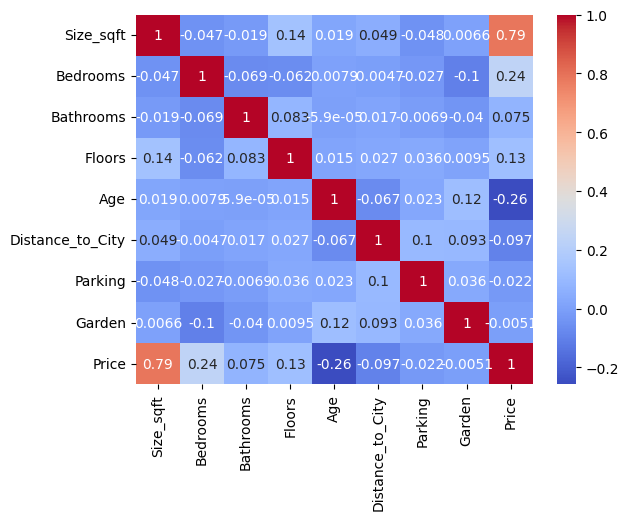

In [ ]:
#Correlation Analysis shows relationship between features.
sns.heatmap(housing_df.corr(), annot=True, cmap='coolwarm')

# strong impact on priceSize, Bedrooms, Floors, and Age 
# are important features for predicting house price.


In [7]:

# Outlier Detection using IQR method
#Detect extreme values in Price column .
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

outliers_price, lower_bound, upper_bound = detect_outliers_iqr(housing_df, 'Price')

print("Number of outliers:", len(outliers_price))
print(outliers_price.head())

Number of outliers: 0
Empty DataFrame
Columns: [Size_sqft, Bedrooms, Bathrooms, Floors, Age, Distance_to_City, Parking, Garden, Price]
Index: []


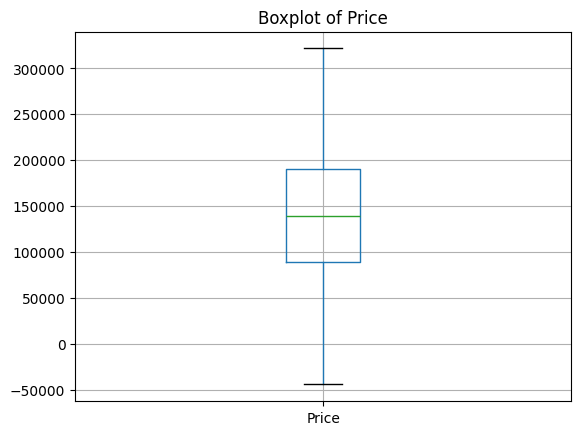

In [12]:
# Visualize outliers using boxplot
housing_df.boxplot(column='Price')
plt.title('Boxplot of Price')
plt.show()

In [13]:
# Remove outliers from the dataset
housing_df_clean = housing_df[(housing_df['Price'] >= lower_bound) & (housing_df['Price'] <= upper_bound)]
print("Original:", housing_df.shape)
print("Cleaned:", housing_df_clean.shape) # there is no outlier in dataset 


Original: (500, 9)
Cleaned: (500, 9)


In [15]:
# Define features and target variable
print("\nTarget Variable: Price")
print("Features:", housing_df_clean.columns.drop("Price"))


Target Variable: Price
Features: Index(['Size_sqft', 'Bedrooms', 'Bathrooms', 'Floors', 'Age',
       'Distance_to_City', 'Parking', 'Garden'],
      dtype='str')


In [17]:
# Fix missing values
housing_df_clean = housing_df_clean.fillna(housing_df_clean.mean())
#Train Model on Cleaned Data and check Performance . 
X_clean = housing_df_clean.drop("Price", axis=1)
y_clean = housing_df_clean["Price"]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=10
)

scaler = StandardScaler()
X_train_clean_scaled = scaler.fit_transform(X_train_clean)
X_test_clean_scaled = scaler.transform(X_test_clean)


model_clean = LinearRegression()  
model_clean.fit(X_train_clean_scaled, y_train_clean)

y_pred_clean = model_clean.predict(X_test_clean_scaled) # pridicted  house price 

rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
r2_clean = r2_score(y_test_clean, y_pred_clean)

print("Clean RMSE:", rmse_clean)
print("Clean R2:", r2_clean)

Clean RMSE: 35252.86007473527
Clean R2: 0.7828344407710291


In [21]:
# fix missing value 
housing_df = housing_df.fillna(housing_df.mean())
# Train Model on Original Data and check  Performance
X = housing_df.drop("Price", axis=1)
y = housing_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Original RMSE:", rmse)
print("Original R2:", r2)

Original RMSE: 35252.86007473527
Original R2: 0.7828344407710291


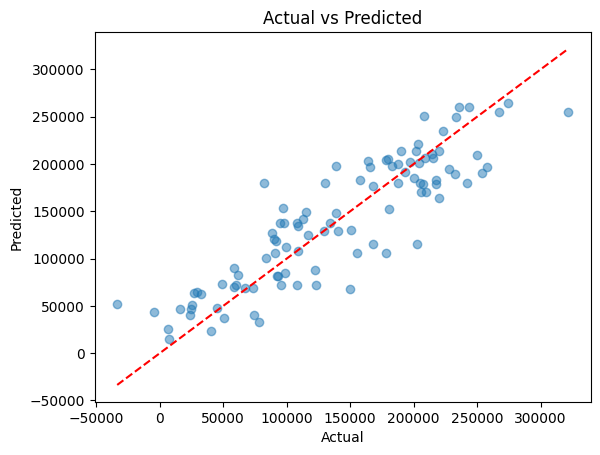

In [22]:
#
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.show()